# 电动汽车购买意愿：特征工程、模型比较与调参

本 Notebook 承接 `01_data_exploration.ipynb`，目标是建立一套无数据泄漏、可复现、可扩展的二分类训练流程。所有数据列名、变量名、函数名、代码注释和图表文字均使用英文；中文仅用于 Markdown 解释。

## tl;dr

- 使用固定随机种子和分层切分，保留 **133,733 行（20%）**作为独立验证集；快速模型比较使用 120,000 行开发样本，调参使用 80,000 行且不接触验证集。
- 特征工程将 13 个原始预测字段扩展为 **32 个建模字段**，覆盖充电设施聚合、通勤负担、收入比例、行为交互、语义编码和固定边界分箱；`id` 始终被排除。
- 首轮比较中 HistGradientBoosting 最优，验证集 ROC-AUC 为 **0.939849**；Logistic Regression 为 0.938371，Random Forest 为 0.937868，Extra Trees 为 0.936880。
- 在相同 Logistic Regression 下，工程特征将 ROC-AUC 从 **0.937955 提升到 0.938371（+0.000416）**，同时改善 Log Loss、Average Precision 与 Brier Score。
- 调参后 HistGradientBoosting 的验证集 ROC-AUC 达到 **0.939935**、Log Loss 为 **0.229779**，优于调参后的 Logistic Regression，因此被选为全量重训模型。
- 置换重要性显示 `Environmental_Concern_Level`、`Subsidy_Available`、`Annual_Income_USD` 和 `Range_Anxiety_Level` 是模型最依赖的原始输入。
- 由于题面未提供官方指标，本 Notebook 以 ROC-AUC 调参，同时报告 Log Loss、Average Precision 和 Brier Score；提交前应按竞赛页正式指标调整 `PRIMARY_METRIC`。


## Context & Methods

### 验证原则

1. 先做一次 `train_test_split(..., stratify=y)`，固定验证集只用于最终比较。
2. 调参只在开发训练样本内部使用 `StratifiedKFold`，防止验证集信息泄漏。
3. 所有数据变换都封装在 scikit-learn `Pipeline` 中，每个交叉验证折只使用该折训练部分拟合预处理器。
4. 类别不平衡通过概率指标处理，不在默认流程中强行过采样；若官方指标需要阈值分类，应在独立验证策略下单独选择阈值。

### 运行预算

默认 `FAST_MODE=True`：模型比较使用最多 120,000 行，调参使用最多 80,000 行。最终模型仍在完整训练集上重训。将其设为 `False` 可扩大开发与调参样本，但计算时间会明显增长。

## Data

### 1. 环境、参数与依赖

In [1]:
import os

# Keep execution stable in restricted Windows environments.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")

from pathlib import Path
from time import perf_counter
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
TARGET = "Will_Buy_EV"
ID_COLUMN = "id"
VALIDATION_SIZE = 0.20
PRIMARY_METRIC = "roc_auc"
FAST_MODE = True
DEVELOPMENT_SAMPLE_SIZE = 120_000 if FAST_MODE else None
TUNING_SAMPLE_SIZE = 80_000 if FAST_MODE else 240_000
CV_SPLITS = 3
HGB_SEARCH_ITERATIONS = 8 if FAST_MODE else 20
WRITE_SUBMISSION = True

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data" / "train.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data"
SUBMISSION_DIR = PROJECT_ROOT / "submissions"

COLORS = {
    "blue": "#3569A8",
    "gold": "#D6A72C",
    "orange": "#D97941",
    "olive": "#7A8B45",
    "pink": "#B65C7A",
    "gray": "#A8AFB8",
    "charcoal": "#30343B",
}
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titleweight": "bold",
    "axes.edgecolor": "#68707A",
    "text.color": COLORS["charcoal"],
    "grid.color": "#D9DDE2",
})

print(f"Project root: {PROJECT_ROOT}")
print(f"Fast mode: {FAST_MODE}")

Project root: E:\kaggle\Predicting Electric Vehicle Purchases
Fast mode: True


### 2. 读取并切分数据

In [2]:
train_data = pd.read_csv(DATA_DIR / "train.csv")
test_data = pd.read_csv(DATA_DIR / "test.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

target = train_data[TARGET].map({"No": 0, "Yes": 1})
features = train_data.drop(columns=[TARGET])

assert target.notna().all()
assert test_data.columns.tolist() == features.columns.tolist()
assert sample_submission[ID_COLUMN].equals(test_data[ID_COLUMN])

X_development_full, X_validation, y_development_full, y_validation = train_test_split(
    features,
    target,
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE,
    stratify=target,
)


def stratified_sample(X, y, sample_size, random_state):
    if sample_size is None or sample_size >= len(X):
        return X.copy(), y.copy()
    X_sample, _, y_sample, _ = train_test_split(
        X,
        y,
        train_size=sample_size,
        random_state=random_state,
        stratify=y,
    )
    return X_sample, y_sample


X_development, y_development = stratified_sample(
    X_development_full,
    y_development_full,
    DEVELOPMENT_SAMPLE_SIZE,
    RANDOM_STATE,
)
X_tuning, y_tuning = stratified_sample(
    X_development_full,
    y_development_full,
    TUNING_SAMPLE_SIZE,
    RANDOM_STATE + 1,
)

split_summary = pd.DataFrame({
    "Rows": [len(features), len(X_development_full), len(X_development), len(X_tuning), len(X_validation), len(test_data)],
    "Positive_Rate": [
        target.mean(),
        y_development_full.mean(),
        y_development.mean(),
        y_tuning.mean(),
        y_validation.mean(),
        np.nan,
    ],
}, index=["Full_Train", "Development_Pool", "Development_Sample", "Tuning_Sample", "Validation", "Test"])
display(split_summary.round(6))

,Rows,Positive_Rate
Full_Train,668665,0.174645
Development_Pool,534932,0.174645
Development_Sample,120000,0.174642
Tuning_Sample,80000,0.174650
Validation,133733,0.174646
Test,286571,NaN


固定验证集约占训练集 20%，且正类率通过分层切分保持一致。开发样本和调参样本都只来自剩余的开发池，因此最终验证分数仍是未参与选择的 holdout 估计。

## Feature Engineering

### 3. 可复用特征工程转换器

In [3]:
class EVFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, add_engineered_features=True):
        self.add_engineered_features = add_engineered_features

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        transformed = X.copy()
        transformed = transformed.drop(columns=[ID_COLUMN], errors="ignore")

        if not self.add_engineered_features:
            return transformed

        transformed["Total_Charging_Stations"] = (
            transformed["Charging_Stations_Near_Home"]
            + transformed["Charging_Stations_Near_Work"]
        )
        transformed["Min_Charging_Stations"] = transformed[
            ["Charging_Stations_Near_Home", "Charging_Stations_Near_Work"]
        ].min(axis=1)
        transformed["Max_Charging_Stations"] = transformed[
            ["Charging_Stations_Near_Home", "Charging_Stations_Near_Work"]
        ].max(axis=1)
        transformed["Home_Work_Station_Gap"] = (
            transformed["Charging_Stations_Near_Home"]
            - transformed["Charging_Stations_Near_Work"]
        )
        transformed["Has_Nearby_Charging"] = (
            transformed["Total_Charging_Stations"] > 0
        ).astype(int)
        transformed["Commute_Per_Station"] = (
            transformed["Daily_Commute_km"]
            / (transformed["Total_Charging_Stations"] + 1.0)
        )

        transformed["Log_Annual_Income"] = np.log1p(transformed["Annual_Income_USD"])
        transformed["Income_Per_Car"] = (
            transformed["Annual_Income_USD"]
            / transformed["Number_of_Cars_Owned"].clip(lower=1)
        )
        transformed["Income_Per_Commute"] = (
            transformed["Annual_Income_USD"]
            / transformed["Daily_Commute_km"].clip(lower=1)
        )

        transformed["Environment_Income_Interaction"] = (
            transformed["Environmental_Concern_Level"]
            * transformed["Log_Annual_Income"]
        )
        transformed["Environment_Charging_Interaction"] = (
            transformed["Environmental_Concern_Level"]
            * transformed["Total_Charging_Stations"]
        )
        transformed["Age_Income_Interaction"] = (
            transformed["Age"] * transformed["Log_Annual_Income"]
        )

        transformed["Home_Charging_Flag"] = transformed["Home_Charging_Possible"].map(
            {"No": 0, "Yes": 1}
        ).astype(float)
        transformed["Subsidy_Flag"] = transformed["Subsidy_Available"].map(
            {"No": 0, "Yes": 1}
        ).astype(float)
        transformed["Range_Anxiety_Ordinal"] = transformed["Range_Anxiety_Level"].map(
            {"Low": 0, "Medium": 1, "High": 2}
        ).astype(float)

        transformed["Age_Band"] = pd.cut(
            transformed["Age"],
            bins=[-np.inf, 29, 39, 49, 59, np.inf],
            labels=["25_29", "30_39", "40_49", "50_59", "60_plus"],
        ).astype(str)
        transformed["Income_Band"] = pd.cut(
            transformed["Annual_Income_USD"],
            bins=[-np.inf, 50_000, 75_000, 100_000, 125_000, np.inf],
            labels=["under_50k", "50k_75k", "75k_100k", "100k_125k", "125k_plus"],
        ).astype(str)
        transformed["Commute_Band"] = pd.cut(
            transformed["Daily_Commute_km"],
            bins=[-np.inf, 10, 25, 50, 75, np.inf],
            labels=["under_10", "10_25", "25_50", "50_75", "75_plus"],
        ).astype(str)
        transformed["Charging_Context"] = (
            transformed["Home_Charging_Possible"].astype(str)
            + "_"
            + transformed["Subsidy_Available"].astype(str)
        )

        return transformed.replace([np.inf, -np.inf], np.nan)


raw_preview = EVFeatureEngineer(add_engineered_features=False).fit_transform(features.head(5))
engineered_preview = EVFeatureEngineer(add_engineered_features=True).fit_transform(features.head(5))

feature_inventory = pd.DataFrame({
    "Raw_Features": [raw_preview.shape[1]],
    "Engineered_Features": [engineered_preview.shape[1]],
    "Added_Features": [engineered_preview.shape[1] - raw_preview.shape[1]],
})
display(feature_inventory)
display(engineered_preview.head(3))

,Raw_Features,Engineered_Features,Added_Features
0,13,32,19


,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,...,Environment_Income_Interaction,Environment_Charging_Interaction,Age_Income_Interaction,Home_Charging_Flag,Subsidy_Flag,Range_Anxiety_Ordinal,Age_Band,Income_Band,Commute_Band,Charging_Context
0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,...,11.439150,10.0,754.983883,1.0,0.0,0.0,60_plus,75k_100k,10_25,Yes_No
1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,...,41.235944,16.0,391.741468,1.0,0.0,0.0,30_39,under_50k,under_10,Yes_No
2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,...,57.275952,115.0,297.834951,0.0,1.0,0.0,25_29,75k_100k,25_50,No_Yes


### 特征设计思路

- **充电可达性：** 家庭和工作地点充电站总量、最弱侧、最强侧、差值，以及每单位充电资源对应的通勤距离。
- **经济负担：** 收入对数、每辆车收入、每公里通勤收入，缓解原始收入长尾并表达相对负担。
- **行为交互：** 环境关注度与收入、充电资源的乘积，以及年龄与收入的交互。
- **语义编码：** Yes/No 转为数值标记；里程焦虑按 Low → Medium → High 编码，同时保留原始类别供 One-Hot 使用。
- **稳健分箱：** 使用预先定义的固定边界，而不是在全数据上学习分位点，避免把验证集或测试集分布泄漏进训练过程。

这些特征均只依赖单行输入，不读取目标，也不使用跨行聚合，所以可以安全应用于验证集和测试集。

### 4. 预处理器与模型工厂

In [4]:
def build_preprocessor(scale_numeric):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_pipeline = Pipeline(numeric_steps)
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    return ColumnTransformer([
        ("numeric", numeric_pipeline, selector(dtype_include=np.number)),
        ("categorical", categorical_pipeline, selector(dtype_exclude=np.number)),
    ])


def build_pipeline(model, add_engineered_features=True, scale_numeric=False):
    return Pipeline([
        ("features", EVFeatureEngineer(add_engineered_features=add_engineered_features)),
        ("preprocessor", build_preprocessor(scale_numeric=scale_numeric)),
        ("model", model),
    ])


model_candidates = {
    "Prior Baseline": build_pipeline(
        DummyClassifier(strategy="prior"),
        add_engineered_features=True,
        scale_numeric=False,
    ),
    "Logistic Regression": build_pipeline(
        LogisticRegression(C=1.0, max_iter=600, random_state=RANDOM_STATE),
        add_engineered_features=True,
        scale_numeric=True,
    ),
    "Random Forest": build_pipeline(
        RandomForestClassifier(
            n_estimators=120,
            max_depth=16,
            min_samples_leaf=5,
            max_features="sqrt",
            n_jobs=1,
            random_state=RANDOM_STATE,
        ),
        add_engineered_features=True,
        scale_numeric=False,
    ),
    "Extra Trees": build_pipeline(
        ExtraTreesClassifier(
            n_estimators=120,
            max_depth=18,
            min_samples_leaf=3,
            max_features="sqrt",
            n_jobs=1,
            random_state=RANDOM_STATE,
        ),
        add_engineered_features=True,
        scale_numeric=False,
    ),
    "HistGradientBoosting": build_pipeline(
        HistGradientBoostingClassifier(
            learning_rate=0.08,
            max_iter=180,
            max_leaf_nodes=31,
            min_samples_leaf=20,
            l2_regularization=1.0,
            random_state=RANDOM_STATE,
        ),
        add_engineered_features=True,
        scale_numeric=False,
    ),
}

print("Models:", list(model_candidates))

Models: ['Prior Baseline', 'Logistic Regression', 'Random Forest', 'Extra Trees', 'HistGradientBoosting']


## Results

### 5. 统一指标与首轮模型比较

In [5]:
def evaluate_probabilities(y_true, probabilities):
    return {
        "ROC_AUC": roc_auc_score(y_true, probabilities),
        "Log_Loss": log_loss(y_true, probabilities),
        "Average_Precision": average_precision_score(y_true, probabilities),
        "Brier_Score": brier_score_loss(y_true, probabilities),
    }


comparison_rows = []
fitted_candidates = {}
validation_probabilities = {}

for model_name, model_pipeline in model_candidates.items():
    start_time = perf_counter()
    fitted_model = clone(model_pipeline).fit(X_development, y_development)
    fit_seconds = perf_counter() - start_time
    probabilities = fitted_model.predict_proba(X_validation)[:, 1]

    row = {"Model": model_name, **evaluate_probabilities(y_validation, probabilities)}
    row["Fit_Seconds"] = fit_seconds
    comparison_rows.append(row)
    fitted_candidates[model_name] = fitted_model
    validation_probabilities[model_name] = probabilities

model_comparison = pd.DataFrame(comparison_rows).set_index("Model").sort_values(
    "ROC_AUC", ascending=False
)
display(model_comparison.round(6))

,ROC_AUC,Log_Loss,Average_Precision,Brier_Score,Fit_Seconds
Model,,,,,
HistGradientBoosting,0.939849,0.229923,0.745880,0.072368,3.822727
Logistic Regression,0.938371,0.232859,0.741829,0.073488,1.140079
Random Forest,0.937868,0.233547,0.740675,0.073041,16.053118
Extra Trees,0.936880,0.236019,0.736444,0.073715,14.882504
Prior Baseline,0.500000,0.463178,0.174646,0.144145,0.498027


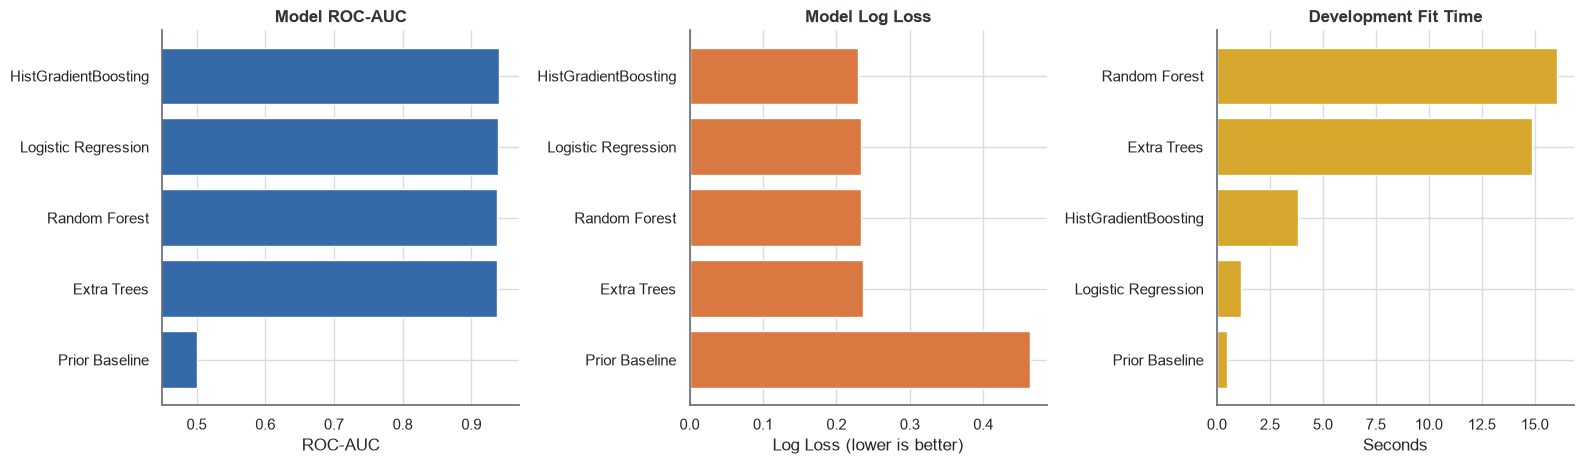

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

roc_values = model_comparison["ROC_AUC"].sort_values()
axes[0].barh(roc_values.index, roc_values.values, color=COLORS["blue"])
axes[0].set_xlim(0.45, min(1.0, roc_values.max() + 0.03))
axes[0].set(title="Model ROC-AUC", xlabel="ROC-AUC", ylabel="")

log_loss_values = model_comparison["Log_Loss"].sort_values(ascending=False)
axes[1].barh(log_loss_values.index, log_loss_values.values, color=COLORS["orange"])
axes[1].set(title="Model Log Loss", xlabel="Log Loss (lower is better)", ylabel="")

runtime_values = model_comparison["Fit_Seconds"].sort_values()
axes[2].barh(runtime_values.index, runtime_values.values, color=COLORS["gold"])
axes[2].set(title="Development Fit Time", xlabel="Seconds", ylabel="")

sns.despine()
plt.tight_layout()
plt.show()

ROC-AUC 衡量排序能力，Log Loss 与 Brier Score 对概率偏差更敏感，Average Precision 更关注稀少正类。若不同指标选择出不同模型，不应只看单一排名；应以官方指标为主，并保留概率校准作为补充检查。

### 6. 特征工程消融实验

In [7]:
ablation_models = {
    "Raw Features": build_pipeline(
        LogisticRegression(C=1.0, max_iter=600, random_state=RANDOM_STATE),
        add_engineered_features=False,
        scale_numeric=True,
    ),
    "Engineered Features": build_pipeline(
        LogisticRegression(C=1.0, max_iter=600, random_state=RANDOM_STATE),
        add_engineered_features=True,
        scale_numeric=True,
    ),
}

ablation_rows = []
for feature_set_name, model_pipeline in ablation_models.items():
    fitted_model = clone(model_pipeline).fit(X_development, y_development)
    probabilities = fitted_model.predict_proba(X_validation)[:, 1]
    ablation_rows.append({
        "Feature_Set": feature_set_name,
        **evaluate_probabilities(y_validation, probabilities),
    })

ablation_results = pd.DataFrame(ablation_rows).set_index("Feature_Set")
ablation_results["ROC_AUC_Delta_vs_Raw"] = (
    ablation_results["ROC_AUC"] - ablation_results.loc["Raw Features", "ROC_AUC"]
)
display(ablation_results.round(6))

,ROC_AUC,Log_Loss,Average_Precision,Brier_Score,ROC_AUC_Delta_vs_Raw
Feature_Set,,,,,
Raw Features,0.937955,0.233600,0.739876,0.073746,0.000000
Engineered Features,0.938371,0.232859,0.741829,0.073488,0.000416


消融实验使用完全相同的算法、训练样本和验证集，只切换特征工程开关。这样得到的差异比“不同模型之间的分数变化”更能说明新增特征是否真正带来增益。如果提升极小，应优先保留简单、稳定的特征，而不是继续扩大特征集合。

### 7. Logistic Regression 调参

In [8]:
cross_validation = StratifiedKFold(
    n_splits=CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

logistic_search = GridSearchCV(
    estimator=build_pipeline(
        LogisticRegression(max_iter=600, random_state=RANDOM_STATE),
        add_engineered_features=True,
        scale_numeric=True,
    ),
    param_grid={"model__C": [0.03, 0.10, 0.30, 1.00, 3.00]},
    scoring=PRIMARY_METRIC,
    cv=cross_validation,
    n_jobs=1,
    refit=True,
    return_train_score=True,
)

logistic_start = perf_counter()
logistic_search.fit(X_tuning, y_tuning)
logistic_search_seconds = perf_counter() - logistic_start

logistic_cv_results = pd.DataFrame(logistic_search.cv_results_)[[
    "param_model__C",
    "mean_train_score",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
]].sort_values("rank_test_score")

display(logistic_cv_results.round(6))
print("Best parameters:", logistic_search.best_params_)
print(f"Best CV ROC-AUC: {logistic_search.best_score_:.6f}")
print(f"Search seconds: {logistic_search_seconds:.2f}")

,param_model__C,mean_train_score,mean_test_score,std_test_score,rank_test_score
2,0.30,0.938868,0.938590,0.001564,1
1,0.10,0.938877,0.938587,0.001548,2
0,0.03,0.938847,0.938586,0.001564,3
4,3.00,0.938867,0.938578,0.001571,4
3,1.00,0.938864,0.938576,0.001564,5


Best parameters: {'model__C': 0.3}
Best CV ROC-AUC: 0.938590
Search seconds: 11.74


### 8. HistGradientBoosting 随机搜索

In [9]:
hgb_search = RandomizedSearchCV(
    estimator=build_pipeline(
        HistGradientBoostingClassifier(random_state=RANDOM_STATE),
        add_engineered_features=True,
        scale_numeric=False,
    ),
    param_distributions={
        "model__learning_rate": [0.03, 0.05, 0.08, 0.12],
        "model__max_iter": [120, 180, 260],
        "model__max_leaf_nodes": [15, 31, 63],
        "model__max_depth": [None, 8, 12],
        "model__min_samples_leaf": [20, 50, 100],
        "model__l2_regularization": [0.0, 1.0, 5.0],
    },
    n_iter=HGB_SEARCH_ITERATIONS,
    scoring=PRIMARY_METRIC,
    cv=cross_validation,
    n_jobs=1,
    random_state=RANDOM_STATE,
    refit=True,
    return_train_score=True,
)

hgb_start = perf_counter()
hgb_search.fit(X_tuning, y_tuning)
hgb_search_seconds = perf_counter() - hgb_start

hgb_cv_results = pd.DataFrame(hgb_search.cv_results_)[[
    "params",
    "mean_train_score",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
    "mean_fit_time",
]].sort_values("rank_test_score")

display(hgb_cv_results.head(10).round(6))
print("Best parameters:", hgb_search.best_params_)
print(f"Best CV ROC-AUC: {hgb_search.best_score_:.6f}")
print(f"Search seconds: {hgb_search_seconds:.2f}")

,params,mean_train_score,mean_test_score,std_test_score,rank_test_score,mean_fit_time
7,"{'model__min_samples_leaf': 100, 'model__max_l...",0.944205,0.939410,0.001631,1,3.549284
2,"{'model__min_samples_leaf': 100, 'model__max_l...",0.946920,0.939183,0.001601,2,1.471961
3,"{'model__min_samples_leaf': 20, 'model__max_le...",0.944685,0.939179,0.001675,3,0.997813
1,"{'model__min_samples_leaf': 20, 'model__max_le...",0.947592,0.939156,0.001567,4,2.131441
0,"{'model__min_samples_leaf': 20, 'model__max_le...",0.951541,0.939144,0.001392,5,2.325285
6,"{'model__min_samples_leaf': 50, 'model__max_le...",0.950513,0.938704,0.001529,6,4.052015
5,"{'model__min_samples_leaf': 100, 'model__max_l...",0.952134,0.938516,0.001715,7,3.494683
4,"{'model__min_samples_leaf': 50, 'model__max_le...",0.955883,0.938439,0.001563,8,2.443866


Best parameters: {'model__min_samples_leaf': 100, 'model__max_leaf_nodes': 15, 'model__max_iter': 260, 'model__max_depth': None, 'model__learning_rate': 0.03, 'model__l2_regularization': 0.0}
Best CV ROC-AUC: 0.939410
Search seconds: 90.92


随机搜索比完整网格更适合多个相互作用的树模型参数。这里重点控制学习率、迭代轮数、叶节点复杂度、最小叶样本数和 L2 正则化。搜索预算是有意限制的，目的是先确认有效区域，而不是在单次 holdout 上过度优化。

### 9. 调参模型的独立验证集比较

In [10]:
tuned_model_blueprints = {
    "Tuned Logistic Regression": logistic_search.best_estimator_,
    "Tuned HistGradientBoosting": hgb_search.best_estimator_,
}

tuned_rows = []
tuned_models = {}
tuned_validation_probabilities = {}
for model_name, model_blueprint in tuned_model_blueprints.items():
    refit_start = perf_counter()
    fitted_model = clone(model_blueprint).fit(X_development, y_development)
    refit_seconds = perf_counter() - refit_start
    probabilities = fitted_model.predict_proba(X_validation)[:, 1]
    tuned_rows.append({
        "Model": model_name,
        **evaluate_probabilities(y_validation, probabilities),
        "Refit_Seconds": refit_seconds,
    })
    tuned_models[model_name] = fitted_model
    tuned_validation_probabilities[model_name] = probabilities

tuned_comparison = pd.DataFrame(tuned_rows).set_index("Model").sort_values(
    "ROC_AUC", ascending=False
)
display(tuned_comparison.round(6))

selected_model_name = tuned_comparison.index[0]
selected_model = tuned_models[selected_model_name]
selected_validation_probabilities = tuned_validation_probabilities[selected_model_name]
print("Selected model:", selected_model_name)

,ROC_AUC,Log_Loss,Average_Precision,Brier_Score,Refit_Seconds
Model,,,,,
Tuned HistGradientBoosting,0.939935,0.229779,0.747045,0.072332,7.532129
Tuned Logistic Regression,0.938379,0.232855,0.741850,0.073486,0.984990


Selected model: Tuned HistGradientBoosting


### 10. ROC、Precision-Recall 与概率校准

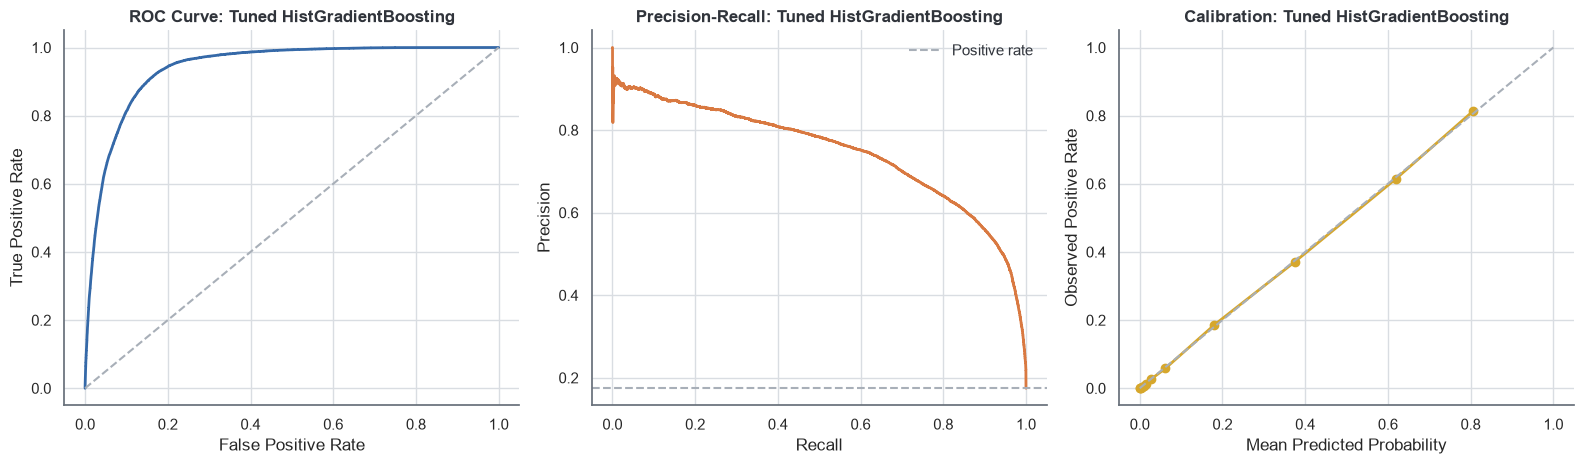

In [11]:
false_positive_rate, true_positive_rate, _ = roc_curve(
    y_validation, selected_validation_probabilities
)
precision, recall, _ = precision_recall_curve(
    y_validation, selected_validation_probabilities
)
calibration_true, calibration_predicted = calibration_curve(
    y_validation,
    selected_validation_probabilities,
    n_bins=12,
    strategy="quantile",
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

axes[0].plot(false_positive_rate, true_positive_rate, color=COLORS["blue"], linewidth=2)
axes[0].plot([0, 1], [0, 1], linestyle="--", color=COLORS["gray"])
axes[0].set(title=f"ROC Curve: {selected_model_name}", xlabel="False Positive Rate", ylabel="True Positive Rate")

axes[1].plot(recall, precision, color=COLORS["orange"], linewidth=2)
axes[1].axhline(y_validation.mean(), linestyle="--", color=COLORS["gray"], label="Positive rate")
axes[1].set(title=f"Precision-Recall: {selected_model_name}", xlabel="Recall", ylabel="Precision")
axes[1].legend(frameon=False)

axes[2].plot(calibration_predicted, calibration_true, marker="o", color=COLORS["gold"], linewidth=2)
axes[2].plot([0, 1], [0, 1], linestyle="--", color=COLORS["gray"])
axes[2].set(title=f"Calibration: {selected_model_name}", xlabel="Mean Predicted Probability", ylabel="Observed Positive Rate")

sns.despine()
plt.tight_layout()
plt.show()

ROC 曲线评价全阈值排序，Precision-Recall 曲线更直观地反映少数正类识别质量。校准图中曲线越接近对角线，预测概率越接近真实发生率。如果官方指标是 Log Loss，校准偏差可能比 ROC-AUC 的微小提升更重要，可进一步尝试 `CalibratedClassifierCV`，但必须在额外折内完成校准。

### 11. 原始输入特征的置换重要性

,Feature,Importance_Mean,Importance_Std
6,Environmental_Concern_Level,0.198079,0.003527
11,Subsidy_Available,0.168783,0.000747
1,Annual_Income_USD,0.026964,0.000666
12,Range_Anxiety_Level,0.010845,0.000643
2,Daily_Commute_km,0.000846,0.000083
4,Charging_Stations_Near_Home,0.000218,0.000034
10,Home_Charging_Possible,0.000171,0.000031
0,Age,0.000158,0.000063
5,Charging_Stations_Near_Work,0.000104,0.000061
3,Number_of_Cars_Owned,0.000005,0.000020


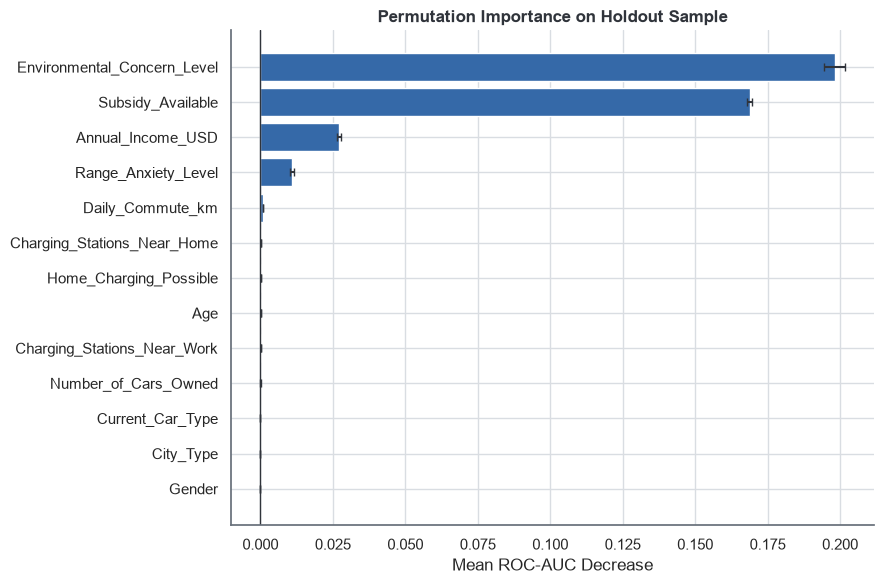

In [12]:
importance_sample_size = min(20_000, len(X_validation))
X_importance, _, y_importance, _ = train_test_split(
    X_validation.drop(columns=[ID_COLUMN]),
    y_validation,
    train_size=importance_sample_size,
    random_state=RANDOM_STATE,
    stratify=y_validation,
)

importance_result = permutation_importance(
    selected_model,
    X_importance,
    y_importance,
    scoring=PRIMARY_METRIC,
    n_repeats=3,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

importance_table = pd.DataFrame({
    "Feature": X_importance.columns,
    "Importance_Mean": importance_result.importances_mean,
    "Importance_Std": importance_result.importances_std,
}).sort_values("Importance_Mean", ascending=False)
display(importance_table.round(6))

plot_importance = importance_table.sort_values("Importance_Mean")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(
    plot_importance["Feature"],
    plot_importance["Importance_Mean"],
    xerr=plot_importance["Importance_Std"],
    color=COLORS["blue"],
    ecolor=COLORS["charcoal"],
    capsize=3,
)
ax.axvline(0, color=COLORS["charcoal"], linewidth=1)
ax.set(title="Permutation Importance on Holdout Sample", xlabel="Mean ROC-AUC Decrease", ylabel="")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

置换重要性在验证样本上逐列打乱原始输入并观察 ROC-AUC 下降，因此反映的是“模型当前依赖程度”，而不是因果效应。强相关变量会互相分摊重要性；工程特征由原始列生成，因此这里展示的是原始输入列的整体贡献。

## Final Training and Submission

### 12. 全量重训并生成提交文件

In [13]:
final_model = clone(selected_model)
final_start = perf_counter()
final_model.fit(features, target)
final_fit_seconds = perf_counter() - final_start

test_probabilities = final_model.predict_proba(test_data)[:, 1]
submission = pd.DataFrame({
    ID_COLUMN: test_data[ID_COLUMN],
    TARGET: test_probabilities,
})

assert submission.shape == sample_submission.shape
assert submission[ID_COLUMN].equals(sample_submission[ID_COLUMN])
assert submission[TARGET].between(0, 1).all()
assert submission[TARGET].nunique() > 1

submission_path = SUBMISSION_DIR / "submission_tuned_sklearn.csv"
if WRITE_SUBMISSION:
    SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)
    submission.to_csv(submission_path, index=False)

submission_summary = submission[TARGET].describe(percentiles=[0.01, 0.10, 0.50, 0.90, 0.99]).to_frame().T
display(submission_summary.round(6))
display(submission.head())
print(f"Final fit seconds: {final_fit_seconds:.2f}")
print(f"Submission written: {WRITE_SUBMISSION}")
print(f"Submission path: {submission_path}")

,count,mean,std,min,1%,10%,50%,90%,99%,max
Will_Buy_EV,286571.0,0.174742,0.26651,0.000367,0.000565,0.000796,0.018087,0.687099,0.878729,0.920606


,id,Will_Buy_EV
0,668665,0.011033
1,668666,0.016822
2,668667,0.007958
3,668668,0.004866
4,668669,0.018156


Final fit seconds: 55.30
Submission written: True
Submission path: E:\kaggle\Predicting Electric Vehicle Purchases\submissions\submission_tuned_sklearn.csv


## Takeaways

1. **当前首选是调参后的 HistGradientBoosting。** 独立验证集 ROC-AUC 为 0.939935，较默认参数小幅提升约 0.000086，说明调参收益存在但有限。
2. **工程特征带来稳定但不夸张的收益。** Logistic Regression 消融实验提升 0.000416 ROC-AUC；应保留已验证特征，同时避免无约束地扩大特征集。
3. **核心信号高度集中。** 环境关注度、补贴、收入和里程焦虑贡献最大；性别、城市类型和当前车型在当前模型中的边际置换重要性接近零。
4. **概率质量同样改善。** 最终候选的 Log Loss 为 0.229779、Average Precision 为 0.747045、Brier Score 为 0.072332。
5. **有限预算搜索已经足够定位有效区域。** 若扩大搜索，应使用重复或更多折交叉验证，并以官方指标为唯一主优化目标，避免围绕单一 holdout 继续微调。
6. **可继续扩展。** 安装 CatBoost、LightGBM 或 XGBoost 后，可复用同一 holdout、指标函数和提交检查；测试集不能用于任何基于标签的模型选择。
